In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "librosa", "soundfile", "audioread", "seaborn", "tqdm"])

0

In [2]:
import os, random, time, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import librosa
import soundfile as sf
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_score, recall_score, f1_score,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

Device: cuda
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [3]:
IS_KAGGLE = Path("/kaggle/input").exists()

def _find_data_root():
    kaggle_in = Path("/kaggle/input")
    if kaggle_in.exists():
        for p in sorted(kaggle_in.rglob("splits/train")):
            return p.parent.parent
    candidates = [
        Path("/kaggle/input/datasets/siddhanta98/cadence-dataset"),
        Path("/kaggle/input/cadence-dataset"),
    ]
    for root in candidates:
        if (root / "splits" / "train").exists():
            return root
    return candidates[0]

WORK_DIR      = Path("/kaggle/working") if IS_KAGGLE else Path(".").resolve()
DATA_ROOT     = _find_data_root()
SPLITS_DIR    = DATA_ROOT / "splits"
PROCESSED_DIR = WORK_DIR / "processed_features"
MODELS_DIR    = WORK_DIR / "models"
RESULTS_DIR   = WORK_DIR / "results"

for d in [PROCESSED_DIR / "train", PROCESSED_DIR / "test", MODELS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

GENRES         = ["tamang_selo", "deuda", "bhajan", "newari", "tharu", "lok_dohori"]
SAMPLE_RATE    = 22050
DURATION       = 30
HOP_LENGTH     = 512
N_BINS         = 84
BINS_PER_OCT   = 12
N_MELS         = 84
TARGET_FRAMES  = 1292

# Training config : tuned to fix overfitting
BATCH_SIZE     = 32   # larger = more stable gradients
NUM_EPOCHS     = 50
LR             = 3e-4
WEIGHT_DECAY   = 5e-4  # stronger L2
NUM_WORKERS    = 2 if IS_KAGGLE and torch.cuda.is_available() else 0

print(f"Data root : {DATA_ROOT}")
print(f"Genres    : {GENRES}")

for split in ["train", "test"]:
    counts = {}
    for g in GENRES:
        gd = SPLITS_DIR / split / g
        counts[g] = len(list(gd.glob("*.wav"))) if gd.exists() else 0
    print(f"{split}: {sum(counts.values())} files : {counts}")

Data root : /kaggle/input/datasets/siddhanta98/cadence-dataset
Genres    : ['tamang_selo', 'deuda', 'bhajan', 'newari', 'tharu', 'lok_dohori']
train: 2903 files : {'tamang_selo': 533, 'deuda': 528, 'bhajan': 413, 'newari': 420, 'tharu': 535, 'lok_dohori': 474}
test: 810 files : {'tamang_selo': 154, 'deuda': 141, 'bhajan': 166, 'newari': 115, 'tharu': 110, 'lok_dohori': 124}


In [4]:
def extract_features(audio_path_or_array, sr=SAMPLE_RATE):
    """
    Returns (4, N_BINS, TARGET_FRAMES) array.
    Channels: harmonic CQT, percussive CQT, mel-spectrogram, delta-mel.
    """
    if isinstance(audio_path_or_array, (str, Path)):
        audio, _ = librosa.load(str(audio_path_or_array), sr=sr, mono=True)
    else:
        audio = audio_path_or_array

    # Pad/trim to fixed duration
    target_len = DURATION * sr
    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))
    else:
        audio = audio[:target_len]

    harmonic, percussive = librosa.effects.hpss(audio)

    def safe_cqt(y):
        try:
            c = np.abs(librosa.cqt(y, sr=sr, hop_length=HOP_LENGTH,
                                   n_bins=N_BINS, bins_per_octave=BINS_PER_OCT))
        except Exception:
            c = np.abs(librosa.feature.melspectrogram(
                y=y, sr=sr, n_mels=N_BINS, hop_length=HOP_LENGTH))
        return librosa.amplitude_to_db(c, ref=np.max)

    cqt_h = safe_cqt(harmonic)
    cqt_p = safe_cqt(percussive)

    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH,
        fmin=20, fmax=8000)
    mel_db = librosa.amplitude_to_db(mel, ref=np.max)
    delta_mel = librosa.feature.delta(mel_db)

    def normalize(x):
        mn, mx = x.min(), x.max()
        return np.zeros_like(x) if (mx - mn) < 1e-9 else (x - mn) / (mx - mn)

    channels = [normalize(cqt_h), normalize(cqt_p),
                normalize(mel_db), normalize(delta_mel)]

    # Pad/trim time axis
    result = []
    for ch in channels:
        t = ch.shape[1]
        if t > TARGET_FRAMES:
            ch = ch[:, :TARGET_FRAMES]
        elif t < TARGET_FRAMES:
            ch = np.pad(ch, ((0, 0), (0, TARGET_FRAMES - t)))
        result.append(ch)

    return np.stack(result, axis=0).astype(np.float32)


def preprocess_all(force=False):
    print("Extracting 4-channel features (CQT-H, CQT-P, Mel, Delta-Mel)...")
    new, skip, err = 0, 0, 0
    for split in ["train", "test"]:
        print(f"\n  Split: {split}")
        for genre in GENRES:
            in_dir  = SPLITS_DIR / split / genre
            out_dir = PROCESSED_DIR / split / genre
            if not in_dir.exists():
                continue
            out_dir.mkdir(parents=True, exist_ok=True)
            wavs = sorted(in_dir.glob("*.wav"))
            for wav in tqdm(wavs, desc=f"    {genre}", leave=False):
                out = out_dir / (wav.stem + ".npy")
                if out.exists() and not force:
                    skip += 1; continue
                try:
                    np.save(str(out), extract_features(wav))
                    new += 1
                except Exception as e:
                    err += 1; print(f"    Error {wav.name}: {e}")
    print(f"\nDone - new: {new}, skipped: {skip}, errors: {err}")

In [5]:
preprocess_all(force=False)

sample = next(PROCESSED_DIR.glob("train/*/*.npy"), None)
if sample:
    arr = np.load(sample)
    print(f"Feature shape: {arr.shape}  (expected: (4, {N_BINS}, {TARGET_FRAMES}))")

Extracting 4-channel features (CQT-H, CQT-P, Mel, Delta-Mel)...

  Split: train


    tamang_selo:   0%|          | 0/533 [00:00<?, ?it/s]

    deuda:   0%|          | 0/528 [00:00<?, ?it/s]

    bhajan:   0%|          | 0/413 [00:00<?, ?it/s]

    newari:   0%|          | 0/420 [00:00<?, ?it/s]

...

    bhajan:   0%|          | 0/166 [00:00<?, ?it/s]

    newari:   0%|          | 0/115 [00:00<?, ?it/s]

    tharu:   0%|          | 0/110 [00:00<?, ?it/s]

    lok_dohori:   0%|          | 0/124 [00:00<?, ?it/s]


Done - new: 3713, skipped: 0, errors: 0
Feature shape: (4, 84, 1292)  (expected: (4, 84, 1292))


In [6]:
class FolkMusicDataset(Dataset):
    def __init__(self, split="train", augment=False):
        self.augment = augment
        self.files, self.labels = [], []

        for label, genre in enumerate(GENRES):
            proc = PROCESSED_DIR / split / genre
            raw  = SPLITS_DIR / split / genre

            if proc.exists() and list(proc.glob("*.npy")):
                for f in sorted(proc.glob("*.npy")):
                    self.files.append((f, True))
                    self.labels.append(label)
            elif raw.exists():
                for f in sorted(raw.glob("*.wav")):
                    self.files.append((f, False))
                    self.labels.append(label)

        if not self.files:
            raise FileNotFoundError(f"No data found for split '{split}'")

        self.labels = np.array(self.labels)
        print(f"  {split}: {len(self.files)} samples")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path, precomputed = self.files[idx]
        label = int(self.labels[idx])
        try:
            feat = np.load(str(path)) if precomputed else extract_features(path)
        except Exception:
            feat = np.zeros((4, N_BINS, TARGET_FRAMES), dtype=np.float32)

        # Ensure correct shape
        if feat.shape != (4, N_BINS, TARGET_FRAMES):
            tmp = np.zeros((4, N_BINS, TARGET_FRAMES), dtype=np.float32)
            h = min(feat.shape[1], N_BINS)
            t = min(feat.shape[2], TARGET_FRAMES)
            tmp[:feat.shape[0], :h, :t] = feat[:4, :h, :t]
            feat = tmp

        return torch.tensor(feat, dtype=torch.float32), label


def get_class_weights():
    """Compute inverse-frequency weights to handle class imbalance."""
    counts = []
    for genre in GENRES:
        d = SPLITS_DIR / "train" / genre
        counts.append(len(list(d.glob("*.wav"))) if d.exists() else 1)
    counts = np.array(counts, dtype=np.float32)
    weights = counts.max() / counts
    return torch.tensor(weights / weights.sum() * len(GENRES), dtype=torch.float32)


def build_loaders():
    pin = torch.cuda.is_available()
    train_ds = FolkMusicDataset("train", augment=True)
    test_ds  = FolkMusicDataset("test",  augment=False)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=pin,
                              persistent_workers=NUM_WORKERS > 0)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=pin,
                              persistent_workers=NUM_WORKERS > 0)
    return train_loader, test_loader

In [7]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation: lets the network re-weight channel importance."""
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4)),
            nn.ReLU(inplace=True),
            nn.Linear(max(channels // reduction, 4), channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1)
        return x * w


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.se    = SEBlock(out_ch)
        self.drop  = nn.Dropout2d(p=dropout)
        self.skip  = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.drop(out)
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out = out + self.skip(x)
        return F.relu(out, inplace=True)


class ImprovedFolkNet(nn.Module):
    def __init__(self, num_classes=6, in_channels=4, dropout=0.35):
        super().__init__()
        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=7, stride=1, padding=3, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        # Encoder blocks - progressively downsample
        self.layer1 = ResBlock(32,  64,  stride=1, dropout=dropout)
        self.pool1  = nn.MaxPool2d(2)
        self.layer2 = ResBlock(64,  128, stride=1, dropout=dropout)
        self.pool2  = nn.MaxPool2d(2)
        self.layer3 = ResBlock(128, 256, stride=1, dropout=dropout)
        self.pool3  = nn.MaxPool2d((1, 2))   # keep freq resolution longer
        self.layer4 = ResBlock(256, 256, stride=1, dropout=dropout)
        self.pool4  = nn.MaxPool2d(2)
        self.layer5 = ResBlock(256, 512, stride=1, dropout=dropout)

        # Multi-scale global pooling : captures both avg and max statistics
        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.gmp    = nn.AdaptiveMaxPool2d(1)

        # Classifier with extra regularization
        self.classifier = nn.Sequential(
            nn.Linear(512 * 2, 256),  # *2 for concat of avg+max
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout * 0.5),
            nn.Linear(128, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stem(x)
        x = self.pool1(self.layer1(x))
        x = self.pool2(self.layer2(x))
        x = self.pool3(self.layer3(x))
        x = self.pool4(self.layer4(x))
        x = self.layer5(x)
        # Multi-scale pooling
        avg = self.gap(x).flatten(1)
        mx  = self.gmp(x).flatten(1)
        x   = torch.cat([avg, mx], dim=1)
        return self.classifier(x)


# Sanity check
_m = ImprovedFolkNet(num_classes=len(GENRES)).to(DEVICE)
_x = torch.randn(2, 4, N_BINS, TARGET_FRAMES, device=DEVICE)
_y = _m(_x)
params = sum(p.numel() for p in _m.parameters())
print(f"Model OK — params: {params:,}, output: {_y.shape}")
del _m, _x, _y
torch.cuda.empty_cache() if torch.cuda.is_available() else None

Model OK — params: 6,468,638, output: torch.Size([2, 6])


In [8]:
def mixup_batch(x, y, alpha=0.3):
    """Mixup: interpolate between two random samples in the batch."""
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    x_mix = lam * x + (1 - lam) * x[idx]
    return x_mix, y, y[idx], lam


def mixup_loss(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


class SpecAugment:
    """Stronger SpecAugment than the baseline."""
    def __init__(self, freq_masks=3, freq_width=15, time_masks=3, time_width=60):
        self.freq_masks  = freq_masks
        self.freq_width  = freq_width
        self.time_masks  = time_masks
        self.time_width  = time_width

    def __call__(self, spec):
        spec = spec.clone()
        C, F, T = spec.shape
        for _ in range(self.freq_masks):
            if F > self.freq_width:
                f = random.randint(1, self.freq_width)
                f0 = random.randint(0, F - f)
                spec[:, f0:f0+f, :] = 0
        for _ in range(self.time_masks):
            if T > self.time_width:
                t = random.randint(1, self.time_width)
                t0 = random.randint(0, T - t)
                spec[:, :, t0:t0+t] = 0
        return spec


def train_one_epoch(model, loader, optimizer, criterion, device,
                    spec_aug, use_mixup=True, mixup_alpha=0.3):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    aug = spec_aug

    for features, labels in tqdm(loader, desc="  Train", leave=False):
        features = features.to(device, non_blocking=True)
        labels   = labels.to(device, non_blocking=True)

        # SpecAugment on each sample
        features = torch.stack([aug(f) for f in features])

        if use_mixup:
            features, y_a, y_b, lam = mixup_batch(features, labels, mixup_alpha)
            optimizer.zero_grad(set_to_none=True)
            out  = model(features)
            loss = mixup_loss(criterion, out, y_a, y_b, lam)
            # Accuracy computed on dominant label only
            preds = out.argmax(1)
            correct += (lam * (preds == y_a).float() +
                        (1 - lam) * (preds == y_b).float()).sum().item()
        else:
            optimizer.zero_grad(set_to_none=True)
            out  = model(features)
            loss = criterion(out, labels)
            correct += (out.argmax(1) == labels).sum().item()

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)  # gradient clipping
        optimizer.step()

        total_loss += loss.item()
        total      += labels.size(0)

    return total_loss / len(loader), 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for features, labels in tqdm(loader, desc="  Eval ", leave=False):
        features = features.to(device, non_blocking=True)
        labels   = labels.to(device, non_blocking=True)
        out      = model(features)
        loss     = criterion(out, labels)
        total_loss  += loss.item()
        all_preds   .extend(out.argmax(1).cpu().numpy())
        all_labels  .extend(labels.cpu().numpy())
    acc    = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=GENRES)
    cm     = confusion_matrix(all_labels, all_preds)
    return total_loss / len(loader), acc, report, cm, all_preds, all_labels

In [9]:
print("Building data loaders...")
train_loader, test_loader = build_loaders()

class_weights = get_class_weights().to(DEVICE)
print(f"Class weights: {dict(zip(GENRES, class_weights.cpu().numpy().round(3)))}")

model     = ImprovedFolkNet(num_classes=len(GENRES), in_channels=4, dropout=0.35).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Cosine annealing : smooth LR decay, eliminates the oscillation from ReduceLROnPlateau
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
spec_aug  = SpecAugment()

best_path = MODELS_DIR / "best_model.pth"
best_acc  = 0.0
history   = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

print(f"\nTraining {NUM_EPOCHS} epochs on {DEVICE}...")
t_start = time.time()

for epoch in range(NUM_EPOCHS):
    # Disable mixup in final 10 epochs for sharper decision boundaries
    use_mixup = epoch < (NUM_EPOCHS - 10)

    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, optimizer, criterion,
        DEVICE, spec_aug, use_mixup=use_mixup, mixup_alpha=0.3)
    te_loss, te_acc, report, cm, _, _ = evaluate(model, test_loader, criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["test_loss"] .append(te_loss)
    history["train_acc"] .append(tr_acc)
    history["test_acc"]  .append(te_acc * 100)

    lr_now = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
          f"Train {tr_acc:.1f}% / {tr_loss:.4f} | "
          f"Test {te_acc*100:.2f}% / {te_loss:.4f} | "
          f"LR {lr_now:.2e}")

    if te_acc > best_acc:
        best_acc = te_acc
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "acc": best_acc,
            "genres": GENRES,
            "in_channels": 4,
        }, best_path)
        print(f"  ✓ Saved best model (acc={best_acc*100:.2f}%)")
        print(report)

    if (epoch + 1) % 10 == 0:
        torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                    "genres": GENRES}, MODELS_DIR / f"checkpoint_epoch_{epoch+1}.pth")

elapsed = (time.time() - t_start) / 60
print(f"\nTraining complete in {elapsed:.1f} min")
print(f"Best test accuracy: {best_acc*100:.2f}%")

Building data loaders...
  train: 2903 samples
  test: 810 samples
Class weights: {'tamang_selo': np.float32(0.897), 'deuda': np.float32(0.905), 'bhajan': np.float32(1.157), 'newari': np.float32(1.138), 'tharu': np.float32(0.894), 'lok_dohori': np.float32(1.009)}

Training 50 epochs on cuda...


  Train:   0%|          | 0/91 [00:00<?, ?it/s]

  Eval :   0%|          | 0/26 [00:00<?, ?it/s]

Epoch   1/50 | Train 26.7% / 1.9105 | Test 43.70% / 1.5324 | LR 3.00e-04
  ✓ Saved best model (acc=43.70%)
              precision    recall  f1-score   support

 tamang_selo       0.49      0.56      0.52       154
       deuda       0.44      0.03      0.05       141
      bhajan       0.51      0.81      0.62       166
      newari       0.27      0.58      0.37       115
       tharu       0.75      0.19      0.30       110
  lok_dohori       0.50      0.33      0.40       124

    accuracy                           0.44       810
   macro avg       0.49      0.42      0.38       810
weighted avg       0.49      0.44      0.39       810



  Train:   0%|          | 0/91 [00:00<?, ?it/s]

...

  Eval :   0%|          | 0/26 [00:00<?, ?it/s]

Epoch  49/50 | Train 97.6% / 0.5354 | Test 75.06% / 1.0044 | LR 1.30e-06
  ✓ Saved best model (acc=75.06%)
              precision    recall  f1-score   support

 tamang_selo       0.94      0.75      0.84       154
       deuda       0.84      0.50      0.62       141
      bhajan       0.89      0.87      0.88       166
      newari       0.58      0.88      0.70       115
       tharu       0.70      0.67      0.69       110
  lok_dohori       0.63      0.82      0.71       124

    accuracy                           0.75       810
   macro avg       0.77      0.75      0.74       810
weighted avg       0.78      0.75      0.75       810



  Train:   0%|          | 0/91 [00:00<?, ?it/s]

  Eval :   0%|          | 0/26 [00:00<?, ?it/s]

Epoch  50/50 | Train 97.0% / 0.5327 | Test 74.44% / 0.9962 | LR 1.00e-06

Training complete in 127.9 min
Best test accuracy: 75.06%


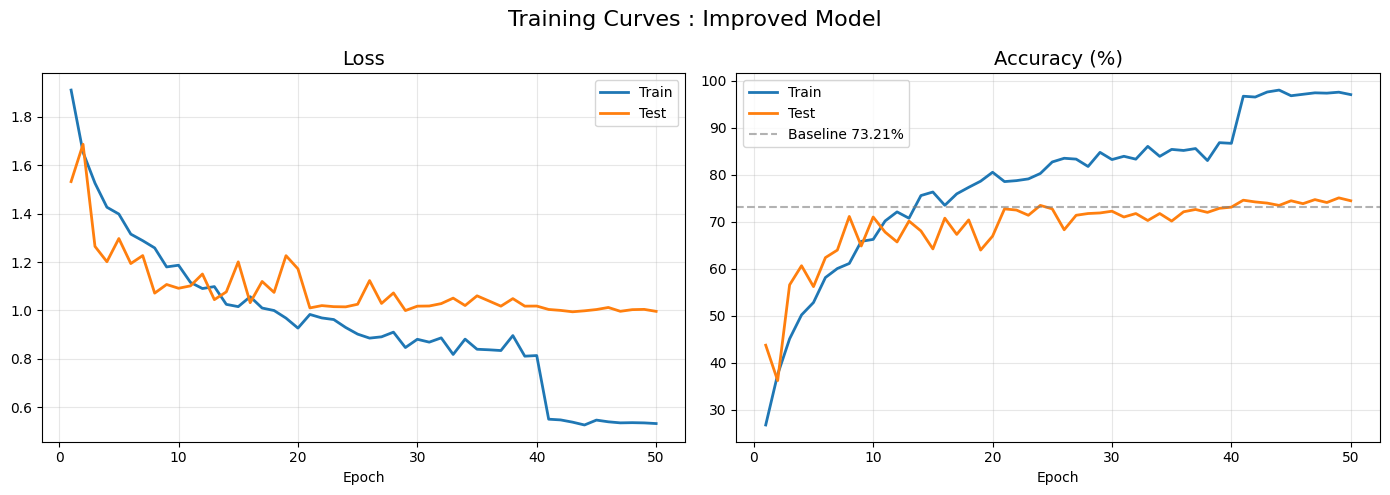

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs, history["train_loss"], label="Train", linewidth=2)
axes[0].plot(epochs, history["test_loss"],  label="Test",  linewidth=2)
axes[0].set_title("Loss", fontsize=14)
axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_acc"], label="Train", linewidth=2)
axes[1].plot(epochs, history["test_acc"],  label="Test",  linewidth=2)
axes[1].axhline(73.21, color="gray", linestyle="--", alpha=0.6, label="Baseline 73.21%")
axes[1].set_title("Accuracy (%)", fontsize=14)
axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Training Curves : Improved Model", fontsize=16)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=150)
plt.show()

Loaded best model from epoch 49 (acc=75.06%)


  Eval :   0%|          | 0/26 [00:00<?, ?it/s]


=== FINAL EVALUATION ===
              precision    recall  f1-score   support

 tamang_selo       0.94      0.75      0.84       154
       deuda       0.84      0.50      0.62       141
      bhajan       0.89      0.87      0.88       166
      newari       0.58      0.88      0.70       115
       tharu       0.70      0.67      0.69       110
  lok_dohori       0.63      0.82      0.71       124

    accuracy                           0.75       810
   macro avg       0.77      0.75      0.74       810
weighted avg       0.78      0.75      0.75       810



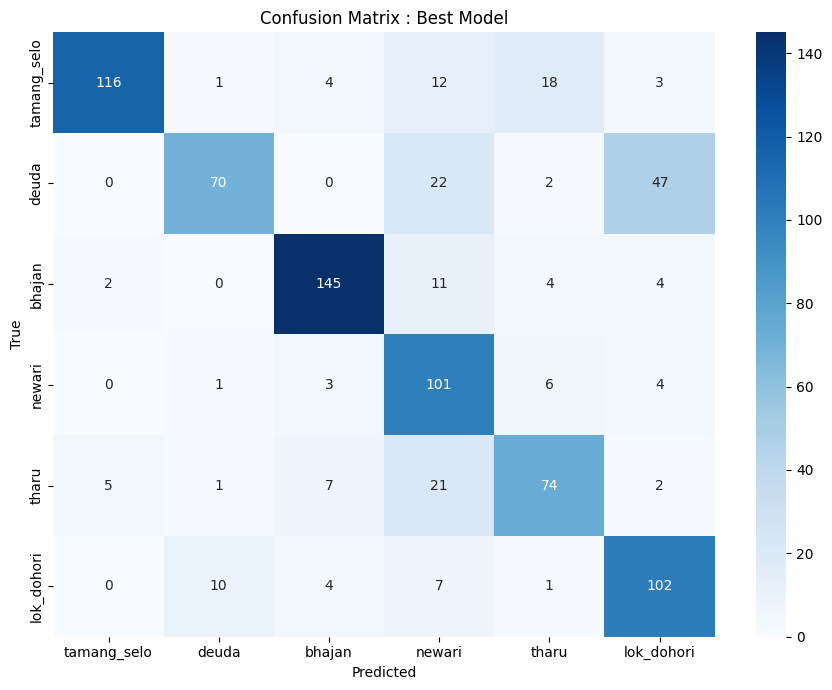

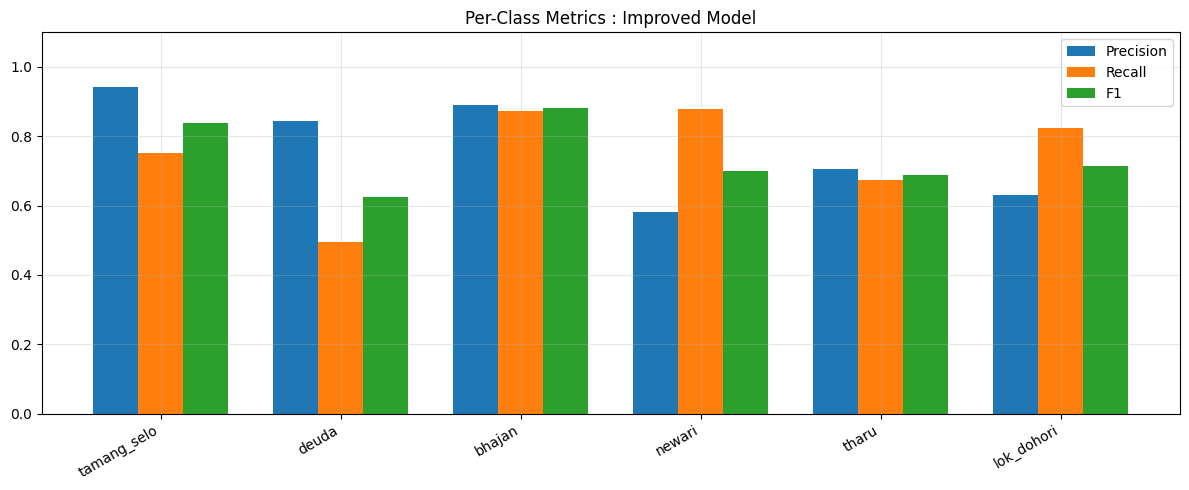


Accuracy : 0.7506
Macro F1 : 0.7408
Baseline : Accuracy=0.7321  Macro-F1=0.7179


In [11]:
# Load best checkpoint
ckpt  = torch.load(best_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded best model from epoch {ckpt['epoch']+1} (acc={ckpt['acc']*100:.2f}%)")

_, _, report, cm, all_preds, all_labels = evaluate(model, test_loader, criterion, DEVICE)

print("\n=== FINAL EVALUATION ===")
print(report)

# Confusion matrix
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=GENRES, yticklabels=GENRES)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix : Best Model")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150)
plt.show()

# Per-class bar chart
prec = precision_score(all_labels, all_preds, average=None, zero_division=0)
rec  = recall_score   (all_labels, all_preds, average=None, zero_division=0)
f1   = f1_score       (all_labels, all_preds, average=None, zero_division=0)
x    = np.arange(len(GENRES)); w = 0.25

plt.figure(figsize=(12, 5))
plt.bar(x - w, prec, w, label="Precision")
plt.bar(x,     rec,  w, label="Recall")
plt.bar(x + w, f1,   w, label="F1")
plt.xticks(x, GENRES, rotation=30, ha="right")
plt.ylim(0, 1.1); plt.legend(); plt.grid(alpha=0.3)
plt.title("Per-Class Metrics : Improved Model")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "per_class_metrics.png", dpi=150)
plt.show()

# Summary
print(f"\nAccuracy : {accuracy_score(all_labels, all_preds):.4f}")
print(f"Macro F1 : {f1_score(all_labels, all_preds, average='macro', zero_division=0):.4f}")
print(f"Baseline : Accuracy=0.7321  Macro-F1=0.7179")

In [12]:
class Predictor:
    def __init__(self, model_path, device=DEVICE):
        self.device = device
        self.model  = ImprovedFolkNet(num_classes=len(GENRES), in_channels=4, dropout=0.35).to(device)
        ckpt = torch.load(model_path, map_location=device, weights_only=False)
        self.model.load_state_dict(ckpt["model_state_dict"])
        self.model.eval()

    def predict(self, audio_path, chunk_overlap=0.5):
        audio, sr = librosa.load(str(audio_path), sr=SAMPLE_RATE, mono=True)
        chunk_len = DURATION * sr
        step = int(chunk_len * (1 - chunk_overlap))

        chunk_probs = []
        for start in range(0, len(audio), step):
            chunk = audio[start:start + chunk_len]
            if len(chunk) < sr * 5:  # skip very short trailing chunks
                break
            feat   = extract_features(chunk, sr)
            tensor = torch.tensor(feat, dtype=torch.float32).unsqueeze(0).to(self.device)
            with torch.no_grad():
                probs = torch.softmax(self.model(tensor), dim=1).cpu().numpy()[0]
            chunk_probs.append(probs)

        avg_probs = np.mean(chunk_probs, axis=0)
        best_idx  = int(np.argmax(avg_probs))

        return {
            "file": str(audio_path),
            "predicted": GENRES[best_idx],
            "confidence": float(avg_probs[best_idx]),
            "probabilities": {g: float(avg_probs[i]) for i, g in enumerate(GENRES)},
            "num_chunks": len(chunk_probs),
        }


predictor = Predictor(best_path)

demo_wav = next(SPLITS_DIR.glob("test/*/*.wav"), None)
if demo_wav:
    result = predictor.predict(demo_wav)
    true_genre = demo_wav.parent.name
    print(f"File     : {demo_wav.name}")
    print(f"True     : {true_genre}")
    print(f"Predicted: {result['predicted']}  (conf={result['confidence']:.3f})")
    print("Probabilities:")
    for g, p in sorted(result["probabilities"].items(), key=lambda x: -x[1]):
        bar = "█" * int(p * 30)
        print(f"  {g:<15} {p:.3f}  {bar}")

File     : saba_nidhaye_prabhu_old_bhaktaraj_bhajan_chunk2.wav
True     : bhajan
Predicted: bhajan  (conf=0.955)
Probabilities:
  bhajan          0.955  ████████████████████████████
  lok_dohori      0.014  
  newari          0.009  
  tharu           0.009  
  deuda           0.008  
  tamang_selo     0.004  
